<a href="https://colab.research.google.com/github/Kumar2004-2009/AI_ML/blob/main/pca/real%20data_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Without PCA

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df=pd.read_csv('train.csv')

In [19]:
df.shape

(42000, 785)

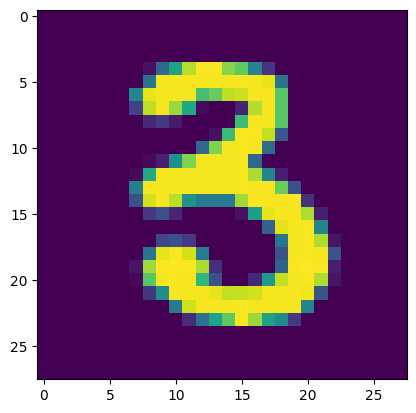

In [20]:
plt.imshow(df.iloc[10301,1:].values.reshape(28,28))

In [21]:
df_cleaned = df.dropna()
X = df_cleaned.iloc[:, 1:]
Y = df_cleaned.iloc[:, 0]

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [15]:
y_pred=knn.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9530038759689923

PCA

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [24]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [25]:
from sklearn.decomposition import PCA
pca=PCA(n_components=200)

In [26]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [27]:
knn=KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [28]:
y_pred=knn.predict(X_test_trf)

In [29]:
accuracy_score(y_test,y_pred)

0.9507142857142857

In [30]:
for i in range(1,785):
  pca=PCA(n_components=i)
  X_train_trf=pca.fit_transform(X_train)
  X_test_trf=pca.transform(X_test)
  knn=KNeighborsClassifier()
  knn.fit(X_train_trf,y_train)
  y_pred=knn.predict(X_test_trf)
  print(i,accuracy_score(y_test,y_pred))

1 0.2580952380952381
2 0.3236904761904762
3 0.5104761904761905
4 0.6663095238095238
5 0.7378571428571429
6 0.8227380952380953
7 0.8436904761904762
8 0.8721428571428571
9 0.886547619047619
10 0.9055952380952381


KeyboardInterrupt: 